In [203]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys

warnings.filterwarnings("ignore")
sys.path.append('../src-double-gyre')
sys.path.append('../src')
from plot_helpers import create_animation_ffmpeg

%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goal
Create calibration dataset for NW2 configuration

In [204]:
data = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R32/R2_FGR3/topography_corrected.nc', decode_times=False)
static = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-short/unparameterized/output/static.nc', decode_times=False).drop_vars('time')

In [205]:
from xgcm import Grid
grid = Grid(static, coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'}
        },
        boundary={'X': 'periodic', 'Y': 'fill'},
        fill_value = {'Y': 0})

# Energetics

In [213]:
from dask.diagnostics import ProgressBar
rho0 = 1000.
scaling = 1.e-15
with ProgressBar():
    KE = scaling * 0.5 * ((grid.interp(data.u**2, 'X') + grid.interp(data.v**2, 'Y')) * data.h * static.area_t * rho0).sum(['xh','yh']).compute()

[########################################] | 100% Completed | 1.42 sms


In [214]:
interface_rest = xr.DataArray([    0.,   -25.,   -75.,  -175.,  -300.,  -450.,  -625.,  -825.,
       -1050., -1300., -1600., -1950., -2350., -2850., -3400., -4000.], dims='zi')

g = xr.DataArray([1.0e+01, 2.1e-03, 3.9e-03, 5.4e-03, 5.8e-03, 5.8e-03, 5.7e-03,
   5.3e-03, 4.8e-03, 4.2e-03, 3.7e-03, 3.1e-03, 2.4e-03, 1.7e-03,
   1.1e-03, 0.0e+00], dims='zi')

area_t = static.area_t
coordinate_of_bottom = - static.depth_ocean

hint = data.e - interface_rest
hbot = np.maximum(coordinate_of_bottom - interface_rest,0)

APE_instant = (0.5 * rho0 * g * (hint**2) * area_t)
APE_constant = (0.5 * rho0 * g * (hbot**2) * area_t)

with ProgressBar():
    APE = scaling * (APE_instant - APE_constant).sum(['xh', 'yh']).compute()

[########################################] | 100% Completed | 1.62 sms


In [215]:
dataset = xr.Dataset()
dataset['KE_mean'] = KE.mean('time')
dataset['APE_mean'] = APE.mean('time')

dataset['KE_std'] = KE.std('time')
dataset['APE_std'] = APE.std('time')

In [217]:
print(KE.sum('zl')[0].item() / scaling)
print(APE.sum('zi')[0].item() / scaling)

1.3339231289727857e+18
9.551214050809541e+19


In [218]:
print(KE[-1][0].item() / scaling)
print(APE[-2][0].item() / scaling)

4.6006815584001384e+16
2.848135051840386e+17


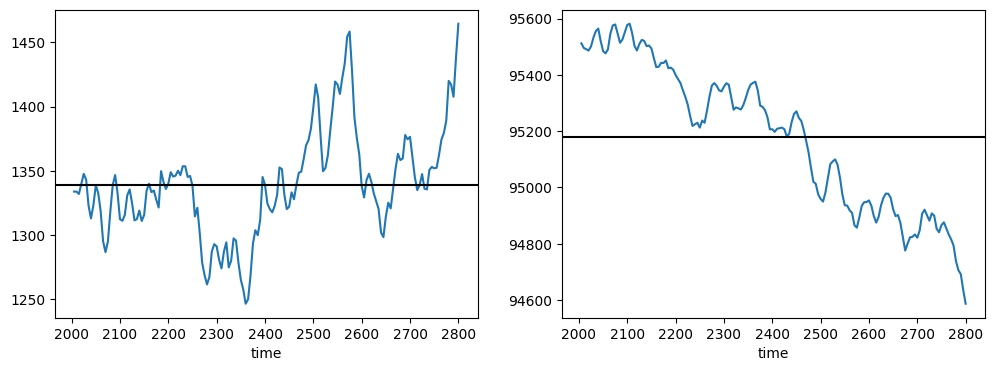

In [219]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
KE.sum('zl').plot()
plt.axhline(y=dataset['KE_mean'].sum('zl'), color='k')
plt.subplot(1,2,2)
APE.sum('zi').plot()
plt.axhline(y=dataset['APE_mean'].sum('zi'), color='k')

# Interfaces

In [220]:
dataset['e_mean'] = data.e.mean('time').compute()
dataset['e_std'] = data.e.std('time').compute()

In [221]:
mask = dataset['e_mean'] > - static.depth_ocean + 10

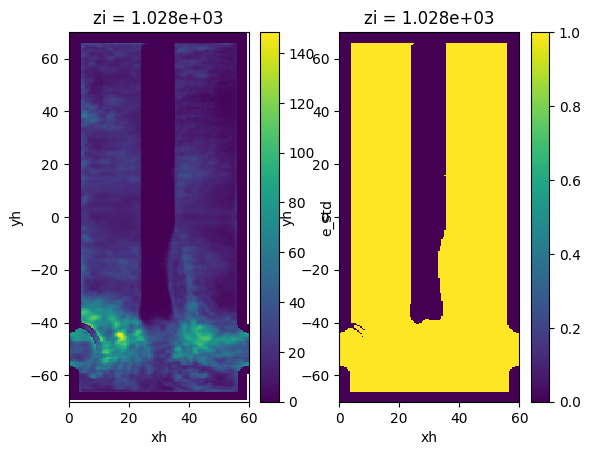

In [222]:
zi = 12
plt.subplot(1,2,1)
dataset['e_std'][zi].plot()
plt.subplot(1,2,2)
mask[zi].plot()

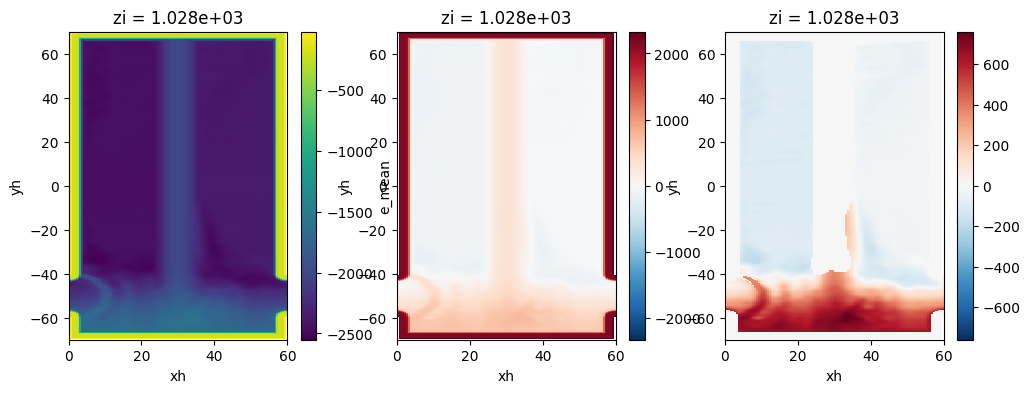

In [223]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
dataset['e_mean'][zi].plot()
plt.subplot(1,3,2)
(dataset['e_mean'] - interface_rest)[zi].plot()
plt.subplot(1,3,3)
(mask*(dataset['e_mean'] - interface_rest))[zi].plot()

# Normalization constants

In [224]:
dataset

<xarray.Dataset> Size: 4MB
Dimensions:   (zl: 15, zi: 16, yh: 280, xh: 120)
Coordinates:
  * zl        (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03 1.028e+03
  * zi        (zi) float64 128B 1.022e+03 1.023e+03 1.023e+03 ... 1.028e+03 nan
  * yh        (yh) float64 2kB -69.75 -69.25 -68.75 -68.25 ... 68.75 69.25 69.75
  * xh        (xh) float64 960B 0.25 0.75 1.25 1.75 ... 58.25 58.75 59.25 59.75
Data variables:
    KE_mean   (zl) float64 120B 43.56 66.74 130.4 98.44 ... 52.32 46.78 37.67
    APE_mean  (zi) float64 128B 402.8 186.2 1.503e+03 4e+03 ... 473.0 286.5 0.0
    KE_std    (zl) float64 120B 3.525 3.44 5.002 3.349 ... 2.185 2.43 2.054
    APE_std   (zi) float64 128B 5.439 1.087 9.88 19.85 ... 16.37 7.104 3.135 0.0
    e_mean    (zi, yh, xh) float32 2MB nan nan nan nan nan ... nan nan nan nan
    e_std     (zi, yh, xh) float32 2MB nan nan nan nan nan ... nan nan nan nan

# Not noise-based normalization constants

In [225]:
# The resulting loss for the energetics is
# (KE-KE_true)**2/KE_true**2
# layerwise
for variable in ['KE_mean', 'KE_std', 'APE_mean', 'APE_std']:
    dataset[f'{variable}_var_loss'] = dataset[variable]**2

In [226]:
dataset['e_std_var_loss'] = (dataset.e_std**2).sum(['xh', 'yh']) + 0 * dataset['e_std']
e_mean_corrected = mask*(dataset['e_mean'] - interface_rest)
dataset['e_mean_var_loss'] = (e_mean_corrected**2).sum(['xh', 'yh']) + 0 * dataset['e_mean']

In [227]:
dataset = dataset.isel(zi=slice(0,-1)).transpose('zl',...).transpose('zi',...)

In [228]:
dataset

<xarray.Dataset> Size: 10MB
Dimensions:            (zl: 15, zi: 15, yh: 280, xh: 120)
Coordinates:
  * zl                 (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * zi                 (zi) float64 120B 1.022e+03 1.023e+03 ... 1.028e+03
  * yh                 (yh) float64 2kB -69.75 -69.25 -68.75 ... 69.25 69.75
  * xh                 (xh) float64 960B 0.25 0.75 1.25 ... 58.75 59.25 59.75
Data variables:
    KE_mean            (zl) float64 120B 43.56 66.74 130.4 ... 52.32 46.78 37.67
    APE_mean           (zi) float64 120B 402.8 186.2 1.503e+03 ... 473.0 286.5
    KE_std             (zl) float64 120B 3.525 3.44 5.002 ... 2.185 2.43 2.054
    APE_std            (zi) float64 120B 5.439 1.087 9.88 ... 16.37 7.104 3.135
    e_mean             (zi, yh, xh) float32 2MB nan nan nan nan ... nan nan nan
    e_std              (zi, yh, xh) float32 2MB nan nan nan nan ... nan nan nan
    KE_mean_var_loss   (zl) float64 120B 1.897e+03 4.454e+03 ... 1.419e+03
    KE_std_var_loss    (zl) float64 120B 12.42 11.84 25.02 ... 4.772 5.907 4.22
    APE_mean_var_loss  (zi) float64 120B 1.623e+05 3.468e+04 ... 8.207e+04
    APE_std_var_loss   (zi) float64 120B 29.59 1.182 97.61 ... 268.1 50.47 9.829
    e_std_var_loss     (zi, yh, xh) float32 2MB nan nan nan nan ... nan nan nan
    e_mean_var_loss    (zi, yh, xh) float64 4MB dask.array<chunksize=(15, 280, 120), meta=np.ndarray>

In [229]:
dataset.astype('float32').fillna(0.).to_netcdf('../scripts/R32_R2_FGR3_NW2/800days.nc')